In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import pearsonr
from sklearn.metrics import log_loss, mean_squared_error
import warnings

# Suppress expected optimization warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Set visual style for plots
sns.set_theme(style="whitegrid")

# 1. Load the cleaned dataset AND drop any remaining NaNs
df = pd.read_csv("DD_master_dataset.csv").dropna().copy()

def scale_positive(x):
    """Max-scaling for L2 regularization while preserving positive values."""
    return x / (np.max(x) + 1e-8)

print(f"Dataset successfully loaded and fully cleaned. Total rows: {len(df)}")
print(f"Total unique subjects: {df['subject_id'].nunique()}")

Dataset successfully loaded and fully cleaned. Total rows: 28838
Total unique subjects: 99


In [9]:
def sigmoid(x):
    """Sigmoid choice rule, clipped to prevent exponential overflow."""
    x = np.clip(x, -50, 50)
    return 1 / (1 + np.exp(-x))

def baseline_nll(params, r_imm, r_del, delay, choices, lambda_reg=0.01):
    """Negative Log-Likelihood for the Choice-Only Baseline."""
    kappa, beta = params
    if kappa <= 0: return 1e10

    v_imm = r_imm
    v_del = r_del / (1 + kappa * delay)
    delta_v = v_imm - v_del

    pi = np.clip(sigmoid(beta * delta_v), 1e-10, 1 - 1e-10)
    nll_choice = -np.sum(choices * np.log(pi) + (1 - choices) * np.log(1 - pi))

    # Reduced penalty to 0.01
    reg = (lambda_reg / 2) * (kappa**2 + beta**2)
    return nll_choice + reg

def joint_nll(params, r_imm, r_del, delay, choices, log_rt, lambda_reg=0.01):
    """Negative Log-Likelihood for the Magnitude + Conflict Joint Model."""
    kappa, beta, beta0, beta1, beta2, sigma2 = params
    if kappa <= 0 or sigma2 <= 0: return 1e10

    v_imm = r_imm
    v_del = r_del / (1 + kappa * delay)
    delta_v = v_imm - v_del

    pi = np.clip(sigmoid(beta * delta_v), 1e-10, 1 - 1e-10)
    nll_choice = -np.sum(choices * np.log(pi) + (1 - choices) * np.log(1 - pi))

    mu = beta0 - beta1 * np.abs(delta_v) + beta2 * (v_imm + v_del)
    nll_rt = np.sum(0.5 * np.log(2 * np.pi * sigma2) + ((log_rt - mu)**2) / (2 * sigma2))

    # Reduced penalty to 0.01
    reg = (lambda_reg / 2) * (kappa**2 + beta**2 + beta1**2 + beta2**2)
    return nll_choice + nll_rt + reg

In [10]:
def fit_with_restarts(obj_func, bounds, args, num_restarts=5):
    """Runs L-BFGS-B multiple times with random inits to find the global minimum."""
    best_nll = np.inf
    best_res = None

    for i in range(num_restarts):
        init_params = []
        for b in bounds:
            low = b[0] if b[0] is not None else -5
            high = b[1] if b[1] is not None else 10
            # Clamp limits specifically for variance and kappa sampling
            if low == 1e-5 or low == 1e-3: high = 2.0
            init_params.append(np.random.uniform(low, high))

        res = minimize(obj_func, init_params, args=args, method='L-BFGS-B', bounds=bounds)
        if res.success and res.fun < best_nll:
            best_nll = res.fun
            best_res = res

    # Fallback to last result if none strictly 'succeeded' but completed
    return best_res if best_res is not None else res

results_list = []
subjects = df['subject_id'].unique()

print("Starting robust inference (this may take a moment)...")

for subj in subjects:
    subj_data = df[df['subject_id'] == subj]
    for run in ['train', 'test']:
        run_data = subj_data[subj_data['run_type'] == run]
        if len(run_data) == 0: continue

        r_imm_scaled = scale_positive(run_data['r_imm'].values)
        r_del_scaled = scale_positive(run_data['r_del'].values)
        delay_scaled = scale_positive(run_data['delay'].values)
        choices = run_data['choice'].values
        log_rt = run_data['log_rt'].values

        # Robust Baseline Fit
        bounds_base = [(1e-5, 5), (-10, 10)]
        res_base = fit_with_restarts(baseline_nll, bounds_base, args=(r_imm_scaled, r_del_scaled, delay_scaled, choices, 0.01))

        # Robust Joint Fit
        bounds_joint = [(1e-5, 5), (-10, 10), (3, 9), (-5, 5), (-5, 5), (1e-3, 5)]
        res_joint = fit_with_restarts(joint_nll, bounds_joint, args=(r_imm_scaled, r_del_scaled, delay_scaled, choices, log_rt, 0.01))

        results_list.append({
            'subject_id': subj, 'run_type': run,
            'k_base': res_base.x[0], 'b_base': res_base.x[1],
            'k_joint': res_joint.x[0], 'b_joint': res_joint.x[1],
            'b0': res_joint.x[2], 'b1': res_joint.x[3], 'b2': res_joint.x[4], 'sigma2': res_joint.x[5]
        })

df_params = pd.DataFrame(results_list)
print("Parameter inference complete.")

Starting robust inference (this may take a moment)...
Parameter inference complete.


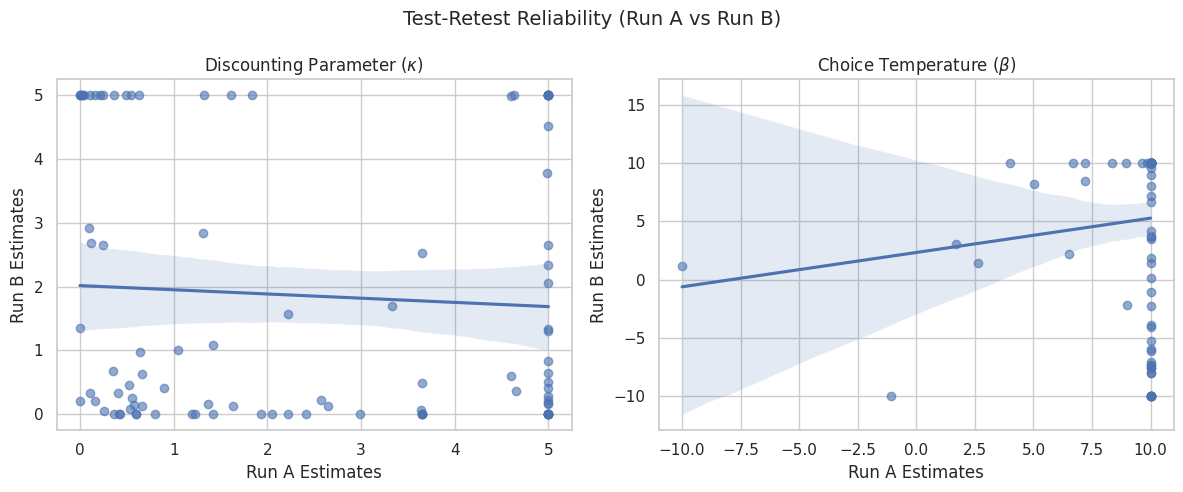

Kappa (κ) Reliability: r = -0.064 (p = 5.319e-01)
Beta (β) Reliability:  r = 0.108 (p = 2.879e-01)


In [11]:
train_params = df_params[df_params['run_type'] == 'train'].set_index('subject_id')
test_params = df_params[df_params['run_type'] == 'test'].set_index('subject_id')
common_subjects = train_params.index.intersection(test_params.index)

train_matched = train_params.loc[common_subjects]
test_matched = test_params.loc[common_subjects]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Test-Retest Reliability (Run A vs Run B)", fontsize=14)

sns.regplot(x=train_matched['k_joint'], y=test_matched['k_joint'], ax=axes[0], scatter_kws={'alpha':0.6})
axes[0].set_title(r"Discounting Parameter ($\kappa$)")
axes[0].set_xlabel("Run A Estimates")
axes[0].set_ylabel("Run B Estimates")

sns.regplot(x=train_matched['b_joint'], y=test_matched['b_joint'], ax=axes[1], scatter_kws={'alpha':0.6})
axes[1].set_title(r"Choice Temperature ($\beta$)")
axes[1].set_xlabel("Run A Estimates")
axes[1].set_ylabel("Run B Estimates")

plt.tight_layout()
plt.show()

# Print metrics to check improvement
r_k, p_k = pearsonr(train_matched['k_joint'], test_matched['k_joint'])
r_b, p_b = pearsonr(train_matched['b_joint'], test_matched['b_joint'])
print(f"Kappa (κ) Reliability: r = {r_k:.3f} (p = {p_k:.3e})")
print(f"Beta (β) Reliability:  r = {r_b:.3f} (p = {p_b:.3e})")

Data Handling Note: Dropped 99 subjects in the 'Loss' condition due to having fewer than 5 trials.
\nWilcoxon Test (Baseline vs Joint Choice Log-Loss): W=1146.0, p=0.1407
Result: Modeling RT did NOT significantly improve out-of-sample choice prediction.


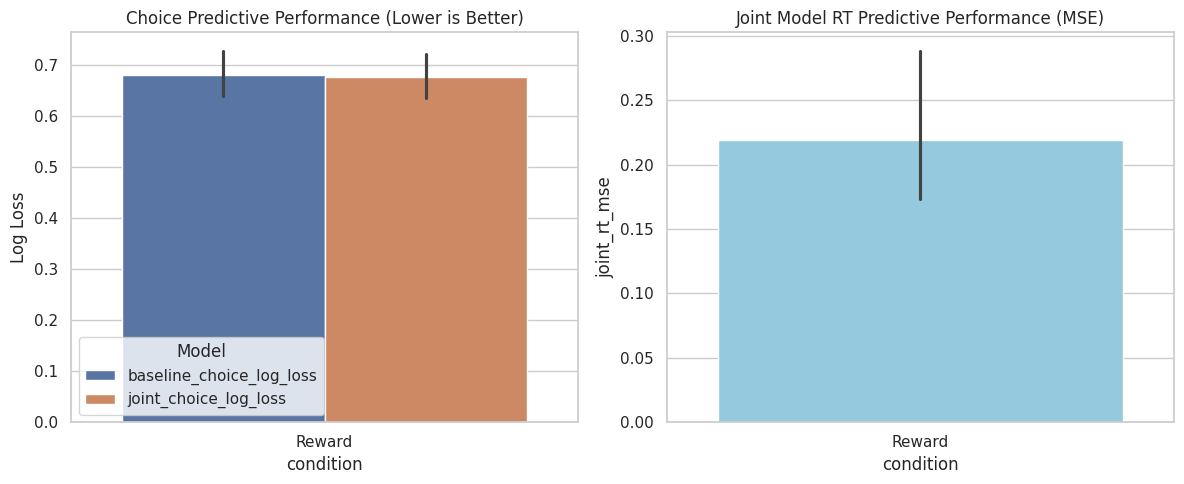

In [15]:
from scipy.stats import wilcoxon

evaluation_results = []
dropped_loss_subjects = 0

for subj in subjects:
    subj_params = df_params[df_params['subject_id'] == subj]
    if len(subj_params[subj_params['run_type'] == 'train']) == 0: continue
    train_p = subj_params[subj_params['run_type'] == 'train'].iloc[0]

    test_data = df[(df['subject_id'] == subj) & (df['run_type'] == 'test')]
    for condition_val, condition_name in zip([1.0, 2.0], ['Reward', 'Loss']):
        cond_data = test_data[test_data['condition'] == condition_val]

        # Explicit Missing Data Handling: Skip sparse conditions
        if len(cond_data) < 5:
            if condition_name == 'Loss':
                dropped_loss_subjects += 1
            continue

        r_imm_t = scale_positive(cond_data['r_imm'].values)
        r_del_t = scale_positive(cond_data['r_del'].values)
        delay_t = scale_positive(cond_data['delay'].values)
        choices_t = cond_data['choice'].values
        log_rt_t = cond_data['log_rt'].values

        # Baseline predictions
        v_del_base = r_del_t / (1 + train_p['k_base'] * delay_t)
        pi_base = np.clip(sigmoid(train_p['b_base'] * (r_imm_t - v_del_base)), 1e-10, 1 - 1e-10)

        # Joint predictions
        v_del_joint = r_del_t / (1 + train_p['k_joint'] * delay_t)
        delta_v_joint = r_imm_t - v_del_joint
        pi_joint = np.clip(sigmoid(train_p['b_joint'] * delta_v_joint), 1e-10, 1 - 1e-10)
        mu_rt = train_p['b0'] - train_p['b1'] * np.abs(delta_v_joint) + train_p['b2'] * (r_imm_t + v_del_joint)

        evaluation_results.append({
            'subject_id': subj, 'condition': condition_name,
            'baseline_choice_log_loss': log_loss(choices_t, pi_base, labels=[0, 1]),
            'joint_choice_log_loss': log_loss(choices_t, pi_joint, labels=[0, 1]),
            'joint_rt_mse': mean_squared_error(log_rt_t, mu_rt)
        })

df_eval = pd.DataFrame(evaluation_results)

print(f"Data Handling Note: Dropped {dropped_loss_subjects} subjects in the 'Loss' condition due to having fewer than 5 trials.")

# --- Statistical Comparison: Does RT Help? ---
reward_eval = df_eval[df_eval['condition'] == 'Reward']
stat, p_val = wilcoxon(reward_eval['baseline_choice_log_loss'], reward_eval['joint_choice_log_loss'])
print(f"\\nWilcoxon Test (Baseline vs Joint Choice Log-Loss): W={stat}, p={p_val:.4f}")
if p_val < 0.05:
    print("Result: Modeling RT significantly changed out-of-sample choice prediction.")
else:
    print("Result: Modeling RT did NOT significantly improve out-of-sample choice prediction.")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_melted_choice = df_eval.melt(id_vars=['condition'], value_vars=['baseline_choice_log_loss', 'joint_choice_log_loss'],
                                var_name='Model', value_name='Log Loss')
sns.barplot(data=df_melted_choice, x='condition', y='Log Loss', hue='Model', ax=axes[0])
axes[0].set_title("Choice Predictive Performance (Lower is Better)")

sns.barplot(data=df_eval, x='condition', y='joint_rt_mse', ax=axes[1], color='skyblue')
axes[1].set_title("Joint Model RT Predictive Performance (MSE)")

plt.tight_layout()
plt.show()

Running side-by-side parameter recovery simulation (Baseline vs Joint)...


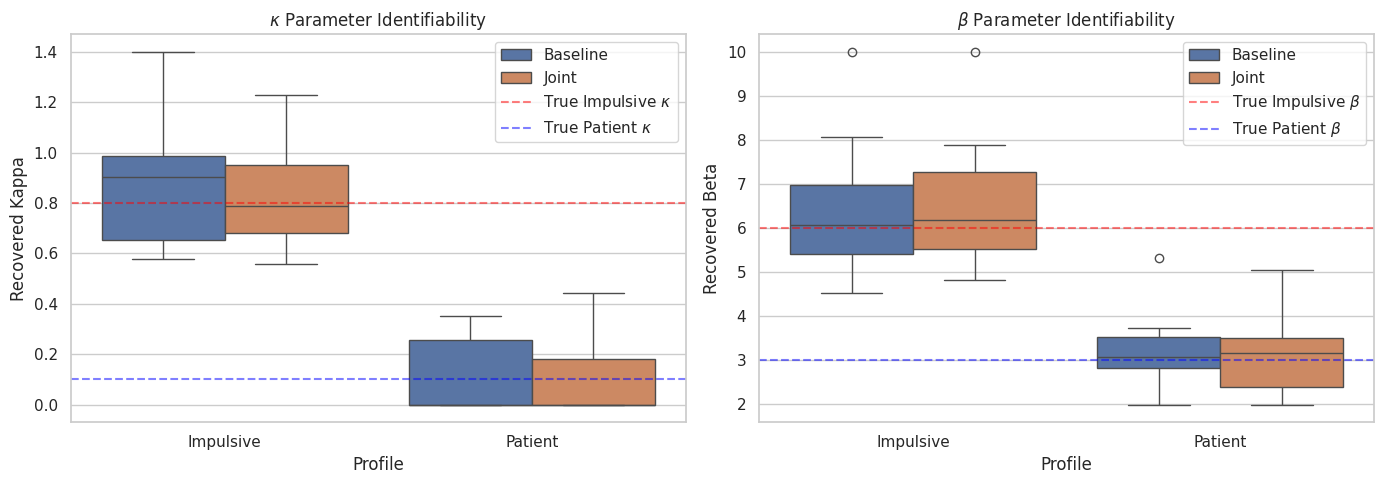

In [16]:
def simulate_synthetic_data(r_imm, r_del, delay, true_params):
    k_true, b_true, b0_true, b1_true, b2_true, s2_true = true_params
    v_imm = r_imm
    v_del = r_del / (1 + k_true * delay)
    delta_v = v_imm - v_del
    pi = np.clip(sigmoid(b_true * delta_v), 1e-10, 1 - 1e-10)
    mu = b0_true - b1_true * np.abs(delta_v) + b2_true * (v_imm + v_del)
    return np.random.binomial(n=1, p=pi), np.random.normal(loc=mu, scale=np.sqrt(s2_true))

sample_subj = df[df['subject_id'] == subjects[0]]
r_imm_sim = scale_positive(sample_subj['r_imm'].values)
r_del_sim = scale_positive(sample_subj['r_del'].values)
delay_sim = scale_positive(sample_subj['delay'].values)

true_params_list = [
    {'name': 'Impulsive', 'params': [0.8, 6.0, 7.2, 1.0, 0.0, 0.2]},
    {'name': 'Patient',   'params': [0.1, 3.0, 7.5, 0.5, 0.2, 0.1]}
]

recovery_data = []
np.random.seed(42)
bounds_base = [(1e-5, 5), (-10, 10)]
bounds_joint = [(1e-5, 5), (-10, 10), (None, None), (-10, 10), (-10, 10), (1e-3, None)]

print("Running side-by-side parameter recovery simulation (Baseline vs Joint)...")

for profile in true_params_list:
    tp = profile['params']
    for i in range(15): # Reduced iterations slightly for speed
        syn_choices, syn_log_rt = simulate_synthetic_data(r_imm_sim, r_del_sim, delay_sim, tp)

        # Baseline Recovery
        res_b = fit_with_restarts(baseline_nll, bounds_base, args=(r_imm_sim, r_del_sim, delay_sim, syn_choices, 0.01), num_restarts=3)
        recovery_data.append({'Profile': profile['name'], 'Model': 'Baseline',
                              'True Kappa': tp[0], 'Recovered Kappa': res_b.x[0],
                              'True Beta': tp[1], 'Recovered Beta': res_b.x[1]})

        # Joint Recovery
        res_j = fit_with_restarts(joint_nll, bounds_joint, args=(r_imm_sim, r_del_sim, delay_sim, syn_choices, syn_log_rt, 0.01), num_restarts=3)
        recovery_data.append({'Profile': profile['name'], 'Model': 'Joint',
                              'True Kappa': tp[0], 'Recovered Kappa': res_j.x[0],
                              'True Beta': tp[1], 'Recovered Beta': res_j.x[1]})

df_recovery = pd.DataFrame(recovery_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot Kappa Recovery
sns.boxplot(data=df_recovery, x='Profile', y='Recovered Kappa', hue='Model', ax=axes[0])
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='True Impulsive $\\kappa$')
axes[0].axhline(y=0.1, color='blue', linestyle='--', alpha=0.5, label='True Patient $\\kappa$')
axes[0].set_title(r"$\kappa$ Parameter Identifiability")
axes[0].legend()

# Plot Beta Recovery
sns.boxplot(data=df_recovery, x='Profile', y='Recovered Beta', hue='Model', ax=axes[1])
axes[1].axhline(y=6.0, color='red', linestyle='--', alpha=0.5, label='True Impulsive $\\beta$')
axes[1].axhline(y=3.0, color='blue', linestyle='--', alpha=0.5, label='True Patient $\\beta$')
axes[1].set_title(r"$\beta$ Parameter Identifiability")
axes[1].legend()

plt.tight_layout()
plt.show()

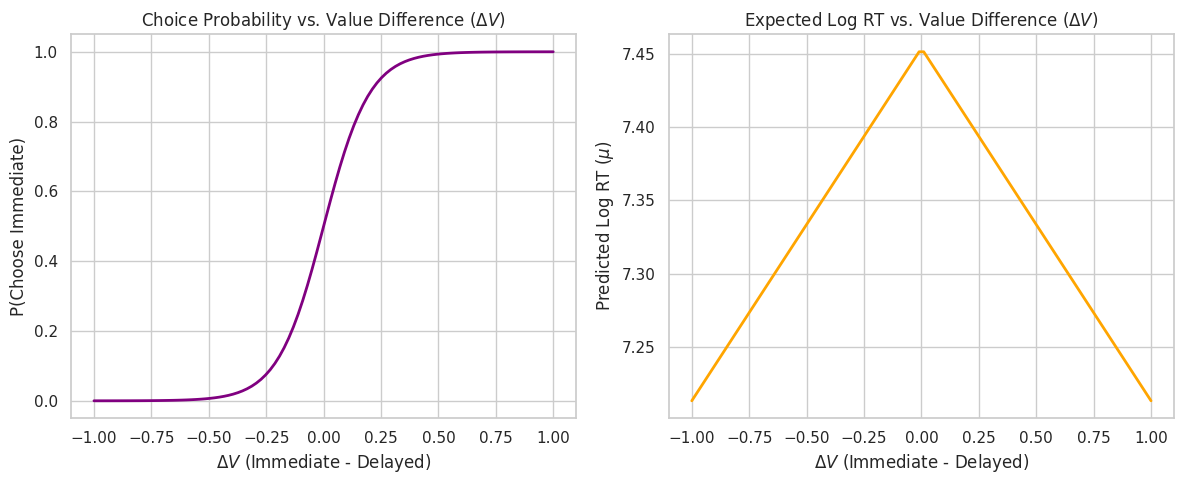

In [17]:
# Simulating a smooth value difference range to plot theoretical curves
delta_v_range = np.linspace(-1, 1, 100)
sample_beta = df_params['b_joint'].median()
sample_b0 = df_params['b0'].median()
sample_b1 = df_params['b1'].median()

pi_curve = sigmoid(sample_beta * delta_v_range)
rt_curve = sample_b0 - sample_b1 * np.abs(delta_v_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(delta_v_range, pi_curve, color='purple', lw=2)
axes[0].set_title(r"Choice Probability vs. Value Difference ($\Delta V$)")
axes[0].set_xlabel(r"$\Delta V$ (Immediate - Delayed)")
axes[0].set_ylabel("P(Choose Immediate)")

axes[1].plot(delta_v_range, rt_curve, color='orange', lw=2)
axes[1].set_title(r"Expected Log RT vs. Value Difference ($\Delta V$)")
axes[1].set_xlabel(r"$\Delta V$ (Immediate - Delayed)")
axes[1].set_ylabel(r"Predicted Log RT ($\mu$)")

plt.tight_layout()
plt.show()